# Production Intent Discovery

Evidence-first clustering and semantic validation on the full AmericanAir corpus. The source JSONL is preserved; labels are written to a versioned output.

In [27]:
import hashlib
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

DATA_PATH = Path("../data/processed/conversations.jsonl")
FAISS_DIR = Path("../data/faiss_opening_index")
META_PATH = FAISS_DIR / "metadata.json"
OUTPUT_PATH = Path("../data/processed/conversations_with_intents_v2.jsonl")
MODEL = "nomic-embed-text:latest"
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


def load_jsonl(path):
    with path.open(encoding="utf-8") as file:
        return [json.loads(line) for line in file if line.strip()]


def sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1048576), b""):
            digest.update(chunk)
    return digest.hexdigest()


conversations = load_jsonl(DATA_PATH)
opening_ids, opening_texts, skipped = [], [], []
context_texts = []
for conversation in conversations:
    messages = conversation.get("messages", [])
    customers = [
        str(message.get("text", "")).strip()
        for message in messages
        if message.get("role") == "customer"
    ]
    context_texts.append(" ".join(customers[:3]))
    if not messages or messages[0].get("role") != "customer":
        skipped.append(str(conversation["conversation_id"]))
        continue
    opening_ids.append(str(conversation["conversation_id"]))
    opening_texts.append(str(messages[0].get("text", "")).strip())

print(
    f"Conversations: {len(conversations):,}; eligible openings: "
    f"{len(opening_ids):,}; skipped: {len(skipped):,} "
    f"({len(skipped) / len(conversations) * 100:.2f}%)"
)
print(
    f"Mean opening chars: {np.mean([len(text) for text in opening_texts]):.1f}; "
    f"context chars: {np.mean([len(text) for text in context_texts]):.1f}"
)

Conversations: 26,388; eligible openings: 26,155; skipped: 233 (0.88%)
Mean opening chars: 137.1; context chars: 208.5


## FAISS provenance validation

In [28]:
from langchain_community.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings

def recover(store):
    count = store.index.ntotal
    matrix = store.index.reconstruct_n(0, count).astype('float32')
    ids, texts = [], []
    for index in range(count):
        document = store.docstore.search(store.index_to_docstore_id[index])
        ids.append(str(document.metadata['conversation_id']))
        texts.append(document.page_content)
    return matrix, ids, texts
assert FAISS_DIR.exists(), 'FAISS index missing; create embeddings first.'
store = FAISS.load_local(str(FAISS_DIR), OllamaEmbeddings(model=MODEL), allow_dangerous_deserialization=True)
embedding_matrix, faiss_ids, faiss_texts = recover(store)
checks = {'count': len(faiss_ids) == len(opening_ids), 'ids': faiss_ids == opening_ids, 'texts': faiss_texts == opening_texts, 'unique_ids': len(faiss_ids) == len(set(faiss_ids)), 'finite': bool(np.isfinite(embedding_matrix).all()), 'dimension': embedding_matrix.ndim == 2 and embedding_matrix.shape[1] > 0}
if META_PATH.exists():
    metadata = json.loads(META_PATH.read_text(encoding='utf-8'))
    checks['model'] = metadata.get('model') == MODEL
    checks['source_hash'] = metadata.get('source_hash') == sha256(DATA_PATH)
else:
    checks['model'] = True; checks['source_hash'] = True
print(checks)
assert all(checks.values()), 'FAISS is stale or mismatched; do not reuse silently.'
normalized = embedding_matrix / np.maximum(np.linalg.norm(embedding_matrix, axis=1, keepdims=True), 1e-12)
META_PATH.write_text(json.dumps({'model': MODEL, 'source_hash': sha256(DATA_PATH), 'count': len(faiss_ids), 'dimension': int(embedding_matrix.shape[1]), 'conversation_ids': faiss_ids}, indent=2), encoding='utf-8')
print(f'Validated {len(faiss_ids):,} vectors, dimension {embedding_matrix.shape[1]}')

{'count': True, 'ids': True, 'texts': True, 'unique_ids': True, 'finite': True, 'dimension': True, 'model': True, 'source_hash': True}
Validated 26,155 vectors, dimension 768


## Model comparison: normalized KMeans and HDBSCAN

In [29]:
import hdbscan
import umap

def evaluate(name, labels, data, parameters):
    labels = np.asarray(labels)
    mask = labels != -1
    values, counts = np.unique(labels[mask], return_counts=True)
    row = {
        "model": name,
        "parameters": parameters,
        "clusters": len(values),
        "noise_pct": (1 - mask.mean()) * 100,
        "min_cluster": int(counts.min()) if len(counts) else 0,
        "max_cluster": int(counts.max()) if len(counts) else 0,
    }
    if len(values) > 1:
        row.update(
            silhouette=silhouette_score(data[mask], labels[mask], metric="cosine"),
            davies_bouldin=davies_bouldin_score(data[mask], labels[mask]),
            calinski_harabasz=calinski_harabasz_score(data[mask], labels[mask]),
        )
    else:
        row.update(silhouette=np.nan, davies_bouldin=np.nan, calinski_harabasz=np.nan)
    return row

rows, kmeans_labels = [], {}
for k in range(6, 21):
    runs = [
        KMeans(n_clusters=k, n_init=20, random_state=seed).fit_predict(normalized)
        for seed in [SEED, SEED + 1, SEED + 2]
    ]
    labels = runs[0]
    row = evaluate("normalized_kmeans", labels, normalized, f"k={k}, n_init=20")
    row["stability_ari"] = np.mean([adjusted_rand_score(labels, other) for other in runs[1:]])
    rows.append(row)
    kmeans_labels[k] = labels

for min_size, min_samples in [(100, 10), (250, 25), (500, 50)]:
    labels = hdbscan.HDBSCAN(
        min_cluster_size=min_size, min_samples=min_samples
    ).fit_predict(normalized)
    row = evaluate(
        "hdbscan", labels, normalized,
        f"min_cluster_size={min_size}, min_samples={min_samples}",
    )
    row["stability_ari"] = np.nan
    rows.append(row)

umap15 = umap.UMAP(
    n_neighbors=30, n_components=15, metric="cosine", random_state=SEED
).fit_transform(normalized)
umap2 = umap.UMAP(
    n_neighbors=30, n_components=2, metric="cosine", random_state=SEED
).fit_transform(normalized)
for min_size, min_samples in [(100, 10), (250, 25), (500, 50)]:
    labels = hdbscan.HDBSCAN(
        min_cluster_size=min_size, min_samples=min_samples
    ).fit_predict(umap15)
    row = evaluate(
        "umap_hdbscan", labels, umap15,
        f"n_components=15, min_cluster_size={min_size}, min_samples={min_samples}",
    )
    row["stability_ari"] = np.nan
    rows.append(row)

tfidf = TfidfVectorizer(
    stop_words="english", min_df=5, max_features=20000, ngram_range=(1, 2)
)
tfidf_matrix = tfidf.fit_transform(opening_texts)
tfidf_labels = KMeans(n_clusters=10, n_init=20, random_state=SEED).fit_predict(tfidf_matrix)
tfidf_row = evaluate("tfidf_kmeans", tfidf_labels, tfidf_matrix.toarray(), "k=10, n_init=20")
tfidf_row["stability_ari"] = np.nan
rows.append(tfidf_row)
tfidf_terms = tfidf.get_feature_names_out()
for cluster_id in range(10):
    term_scores = np.asarray(tfidf_matrix[tfidf_labels == cluster_id].mean(axis=0)).ravel()
    top_terms = [tfidf_terms[i] for i in np.argsort(term_scores)[-10:][::-1]]
    print(f"TFIDF topic {cluster_id}: {', '.join(top_terms)}")

model_results = pd.DataFrame(rows)
display(model_results.sort_values("silhouette", ascending=False))
print("Low scores indicate overlapping language and/or insufficient opening context, not proof that one k is correct.")

e:\01_Projects\02_Main\Hiver_2\customer_support_agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
e:\01_Projects\02_Main\Hiver_2\customer_support_agent\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
e:\01_Projects\02_Main\Hiver_2\customer_support_agent\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


TFIDF topic 0: plane, americanair, americanair plane, flight, sitting, hour, hours, delayed, https, just
TFIDF topic 1: flight, americanair, delayed, time, just, hours, hour, flight americanair, cancelled, help
TFIDF topic 2: americanair https, https, americanair, thanks, flight, great, flying, morning, thank, day
TFIDF topic 3: americanair, flights, fly, flying, time, just, bag, help, aa, amp
TFIDF topic 4: https, americanair, flight, thank, amp, great, travel, home, like, flying
TFIDF topic 5: customer service, customer, service, americanair, americanair customer, worst customer, worst, flight, americanair worst, just
TFIDF topic 6: gate, americanair, gate agent, agent, americanair gate, flight, gate agents, agents, bag, check
TFIDF topic 7: seat, americanair, flight, window, https, paid, middle, window seat, middle seat, class
TFIDF topic 8: americanair flight, flight, americanair, delayed, https, flight delayed, attendant, flight attendant, crew, hours
TFIDF topic 9: thanks, thanks

,model,parameters,clusters,noise_pct,min_cluster,max_cluster,silhouette,davies_bouldin,calinski_harabasz,stability_ari
19,umap_hdbscan,"n_components=15, min_cluster_size=250, min_sam...",2,0.122348,262,25861,0.912040,0.212527,5979.529182,NaN
18,umap_hdbscan,"n_components=15, min_cluster_size=100, min_sam...",2,0.122348,262,25861,0.912040,0.212527,5979.529182,NaN
15,hdbscan,"min_cluster_size=100, min_samples=10",2,97.878035,192,363,0.391728,1.760992,161.705687,NaN
20,umap_hdbscan,"n_components=15, min_cluster_size=500, min_sam...",4,17.052189,558,18216,0.250871,0.954681,2503.031985,NaN
0,normalized_kmeans,"k=6, n_init=20",6,0.000000,2210,5250,0.035471,4.499343,569.208898,0.999217
6,normalized_kmeans,"k=12, n_init=20",12,0.000000,275,3905,0.033371,4.392192,364.702094,0.556039
1,normalized_kmeans,"k=7, n_init=20",7,0.000000,2170,4570,0.032939,4.554713,519.872621,0.994257
14,normalized_kmeans,"k=20, n_init=20",20,0.000000,272,1983,0.031303,4.345953,263.208053,0.753171
10,normalized_kmeans,"k=16, n_init=20",16,0.000000,273,2409,0.029717,4.372122,304.696989,0.747436
5,normalized_kmeans,"k=11, n_init=20",11,0.000000,275,3866,0.028849,4.419867,385.553772,0.700783


Low scores indicate overlapping language and/or insufficient opening context, not proof that one k is correct.


## Central, boundary, and random examples

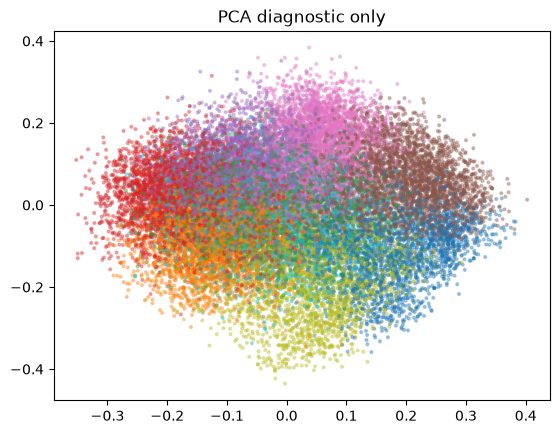


CLUSTER 0 | size=2,338
-- CENTRAL --
[1237731] @AmericanAir &gt;&gt;
[2492593] @AmericanAir hey I gotta a problem
[1369171] @AmericanAir Cheers !! https://t.co/ug1jCmca2F
[265714] 🤔🤨🙄 @AmericanAir https://t.co/r14ygceuFw
[2173715] @AmericanAir This is you guys. https://t.co/I5vpXkUN0W
[1752756] @AmericanAir thanks https://t.co/9VXnwaOtZJ
[2282583] Yessssss 🙌🏼✈️ @AmericanAir https://t.co/DILzV9gkty
[2772165] @AmericanAir thank you https://t.co/mwJy0WrGRe
[1655274] @AmericanAir ??????????
[2152719] @AmericanAir Thanks for your support!!!
Hoaaaah! https://t.co/LPL9R7WphS
-- BOUNDARY --
[2714932] Does anyone know what steps to take after you’ve been sexually assaulted by a female @120943 officer?. @116147 @AmericanAir #MeToo
[924398] @AmericanAir trying to modify my last name online, but option is greyed out! Any advise on how to do this?
[1858365] How is a pixel not a supported device to stream movies? What the fuck @AmericanAir, phone isn't even new anymore.
[2524727] It is actually har

In [30]:
SELECTED_K = 10
labels = kmeans_labels[SELECTED_K]
pca_2d = PCA(2, random_state=SEED).fit_transform(normalized)
plt.scatter(pca_2d[:, 0], pca_2d[:, 1], c=labels, s=4, alpha=.35, cmap='tab10'); plt.title('PCA diagnostic only'); plt.show()
def inspect_cluster(cluster_id, limit=10):
    indices = np.where(labels == cluster_id)[0]; center = normalized[indices].mean(0); center /= max(np.linalg.norm(center), 1e-12); distances = 1 - normalized[indices] @ center; order = np.argsort(distances)
    print(f'\nCLUSTER {cluster_id} | size={len(indices):,}')
    for title, chosen in [('CENTRAL', order[:limit]), ('BOUNDARY', order[-limit:]), ('RANDOM', np.random.default_rng(SEED).choice(len(indices), min(limit, len(indices)), replace=False))]:
        print('--', title, '--')
        for position in chosen: print(f'[{opening_ids[indices[position]]}] {opening_texts[indices[position]]}')
for cluster_id in range(SELECTED_K): inspect_cluster(cluster_id)

## Evidence summary before taxonomy

No intent labels are assigned in this stage. Review model metrics, representation coverage, distinctive terms, and central/boundary/random examples before defining the taxonomy.

In [31]:
cluster_sizes = pd.Series(labels).value_counts().sort_index()
cluster_summary = pd.DataFrame({
    "cluster": cluster_sizes.index,
    "count": cluster_sizes.values,
    "percent": (cluster_sizes.values / len(labels) * 100).round(2),
})

term_summary = {}
for cluster_id in range(SELECTED_K):
    indices = np.where(labels == cluster_id)[0]
    vectorizer = TfidfVectorizer(stop_words="english", max_features=12, ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([opening_texts[index] for index in indices])
    scores = np.asarray(matrix.mean(axis=0)).ravel()
    term_summary[cluster_id] = [
        vectorizer.get_feature_names_out()[index]
        for index in np.argsort(scores)[-10:][::-1]
    ]

print("Cluster sizes:")
display(cluster_summary)
print("Distinctive TF-IDF terms by cluster:")
for cluster_id, terms in term_summary.items():
    print(f"{cluster_id}: {', '.join(terms)}")

print("Review complete. Define intent names only after considering model_results, cluster sizes, terms, and all examples above.")

Cluster sizes:


,cluster,count,percent
0,0,2338,8.94
1,1,2767,10.58
2,2,2206,8.43
3,3,3492,13.35
4,4,3385,12.94
5,5,3170,12.12
6,6,3228,12.34
7,7,1560,5.96
8,8,1984,7.59
9,9,2025,7.74


Distinctive TF-IDF terms by cluster:
0: americanair, https, americanair https, just, help, dm, don, hey, en, que
1: americanair, flight, fly, airline, worst, service, flying, customer, experience, just
2: americanair, flight, ticket, change, https, miles, flights, pay, just, aa
3: americanair, flight, delayed, delay, hours, hour, time, gate, plane, americanair flight
4: americanair, flight, https, plane, flights, americanair flight, time, just, fly, flying
5: americanair, https, thanks, thank, americanair https, great, today, home, amp, just
6: americanair, flight, https, thanks, great, americanair flight, thank, flying, today, crew
7: americanair, seat, seats, flight, https, class, plane, just, amp, boarding
8: americanair, service, customer, customer service, https, help, just, phone, gate, aa
9: americanair, bag, bags, check, luggage, baggage, flight, https, carry, checked
Review complete. Define intent names only after considering model_results, cluster sizes, terms, and all exampl

## Final taxonomy and safe versioned output

This is intentionally after all model comparisons and semantic inspection. Define labels from the evidence above, document boundaries, then write a new versioned file without modifying the source.

In [32]:
# Final taxonomy is defined only after the full model comparison and example audit.
# Cluster IDs below refer to the current SELECTED_K=10 run, not an older run.
cluster_to_intent = {
    0: "Non-actionable social",
    1: "General dissatisfaction",
    2: "Booking fees",
    3: "Flight delay",
    4: "Flight disruption",
    5: "Social thanks",
    6: "Positive experience",
    7: "Seat upgrades",
    8: "Service complaint",
    9: "Baggage issues",
}
intent_definitions = {
    "Non-actionable social": "Mention, link, reaction, or unrelated/social post with no clear support request or operational issue.",
    "General dissatisfaction": "Broad negative airline experience where no single delay, disruption, booking, seat, baggage, or service issue dominates.",
    "Booking fees": "Reservation, ticket, fare, payment, change, voucher, charge, or compensation issue.",
    "Flight delay": "A late departure, arrival, gate, or waiting-time problem is the main issue.",
    "Flight disruption": "Cancellation, missed connection, mechanical issue, tarmac hold, rerouting, or flight-status disruption.",
    "Social thanks": "Thanks, congratulations, acknowledgement, or brief positive contact without a concrete support issue.",
    "Positive experience": "Praise for a completed flight, crew, staff, or overall travel experience.",
    "Seat upgrades": "Seat assignment, seat change, aisle, legroom, cabin, or upgrade issue.",
    "Service complaint": "Complaint about customer service, agents, staff, responsiveness, or support quality.",
    "Baggage issues": "Lost, delayed, damaged, checked, carry-on, or luggage-handling issue.",
}
assert set(cluster_to_intent) == set(range(SELECTED_K))
assert set(cluster_to_intent.values()) == set(intent_definitions)
assert all(1 <= len(label.split()) <= 3 for label in cluster_to_intent.values())

definition_df = pd.DataFrame({
    "intent": list(intent_definitions),
    "definition": list(intent_definitions.values()),
})
display(definition_df)

intent_by_id = {
    conversation_id: cluster_to_intent[int(cluster_label)]
    for conversation_id, cluster_label in zip(opening_ids, labels)
}
temp_path = OUTPUT_PATH.with_suffix(".tmp")
with DATA_PATH.open(encoding="utf-8") as source, temp_path.open("w", encoding="utf-8") as target:
    for line in source:
        if line.strip():
            record = json.loads(line)
            intent = intent_by_id.get(str(record["conversation_id"]))
            record["intent"] = intent
            record["intent_source"] = "normalized_kmeans_after_evidence_review" if intent else "unclassified_opening"
            target.write(json.dumps(record, ensure_ascii=False) + "\n")
temp_path.replace(OUTPUT_PATH)

output = load_jsonl(OUTPUT_PATH)
counts = pd.Series([
    record["intent"] or "Unclassified"
    for record in output
]).value_counts()
display(counts.to_frame("count").assign(percent=lambda frame: frame["count"] / len(output) * 100))
print(f"Wrote versioned output: {OUTPUT_PATH}")
print(f"Source preserved: {DATA_PATH}")

,intent,definition
0,Non-actionable social,"Mention, link, reaction, or unrelated/social p..."
1,General dissatisfaction,Broad negative airline experience where no sin...
2,Booking fees,"Reservation, ticket, fare, payment, change, vo..."
3,Flight delay,"A late departure, arrival, gate, or waiting-ti..."
4,Flight disruption,"Cancellation, missed connection, mechanical is..."
5,Social thanks,"Thanks, congratulations, acknowledgement, or b..."
6,Positive experience,"Praise for a completed flight, crew, staff, or..."
7,Seat upgrades,"Seat assignment, seat change, aisle, legroom, ..."
8,Service complaint,"Complaint about customer service, agents, staf..."
9,Baggage issues,"Lost, delayed, damaged, checked, carry-on, or ..."


,count,percent
Flight delay,3492,13.233288
Flight disruption,3385,12.827801
Positive experience,3228,12.232833
Social thanks,3170,12.013036
General dissatisfaction,2767,10.485827
Non-actionable social,2338,8.860088
Booking fees,2206,8.359861
Baggage issues,2025,7.673943
Service complaint,1984,7.518569
Seat upgrades,1560,5.911778


Wrote versioned output: ..\data\processed\conversations_with_intents_v2.jsonl
Source preserved: ..\data\processed\conversations.jsonl
